# 03 Ridge Baseline

This notebook extends the HAR-RV baseline with a regularized linear model.

The goal is to keep the model interpretable while letting it use a richer but still compact feature set. Compared with HAR-RV, Ridge can absorb correlated volatility, range, liquidity, market, and macro signals without letting the coefficients become unstable.

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_DIR = Path('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project')
DATA_DIR = PROJECT_DIR / 'data'
FIGURE_DIR = PROJECT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DF_PATH = DATA_DIR / 'model_df_2016_2025.csv.gz'

try:
    mpl_dir = PROJECT_DIR / '.matplotlib'
    mpl_dir.mkdir(exist_ok=True)
except PermissionError:
    mpl_dir = Path('/tmp/erdos_vol_pred_runtime/.matplotlib')
    mpl_dir.mkdir(parents=True, exist_ok=True)

os.environ['MPLCONFIGDIR'] = str(mpl_dir)

assert MODEL_DF_PATH.exists(), f'Run 01_data_download_and_features.ipynb first: {MODEL_DF_PATH}'
PROJECT_DIR

PosixPath('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project')

## Why this feature set

Ridge gets a deliberately **small and stable** feature set. We want to test whether a stronger linear model can beat HAR-RV once we add a few carefully chosen extra signals.

The features are grouped into four buckets:

- stock volatility core: recent realized volatility at 5d, 21d, and 63d,
- intraday and liquidity signals: range, Parkinson volatility, volume surprise, and recent absolute returns,
- market context: broad market volatility and return proxies,
- macro and credit context: VIX, rates, and credit ETFs.

This is intentionally more compact than the XGBoost setup, because Ridge is most useful when we keep the model interpretable and reduce the risk of noisy coefficients.

In [2]:
model_df = pd.read_csv(MODEL_DF_PATH, parse_dates=['Date'])

ridge_numeric_features = [
    'realized_vol_5d',
    'realized_vol_21d',
    'realized_vol_63d',
    'high_low_log_range',
    'parkinson_vol_5d',
    'volume_zscore_21d',
    'abs_return_mean_5d',
    'mkt_SPY_proxy_hist_vol_5d',
    'mkt_QQQ_proxy_hist_vol_21d',
    'mkt_IWM_proxy_return',
    'macro_^VIX_proxy_level_zscore_21d',
    'macro_^TNX_proxy_return',
    'macro_HYG_proxy_return',
    'macro_LQD_proxy_return',
]
categorical_features = ['Ticker']
selected_tickers = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM']
alpha_grid = [0.1, 1, 3, 10, 30, 100]
validation_years = [2020, 2021, 2022, 2023, 2024]
test_year = 2025

ridge_model_df = model_df[['Date', 'Ticker', 'fvol_5d', 'log_fvol_5d'] + ridge_numeric_features].copy()
ridge_model_df.head()

,Date,Ticker,fvol_5d,log_fvol_5d,realized_vol_5d,realized_vol_21d,realized_vol_63d,high_low_log_range,parkinson_vol_5d,volume_zscore_21d,abs_return_mean_5d,mkt_SPY_proxy_hist_vol_5d,mkt_QQQ_proxy_hist_vol_21d,mkt_IWM_proxy_return,macro_^VIX_proxy_level_zscore_21d,macro_^TNX_proxy_return,macro_HYG_proxy_return,macro_LQD_proxy_return
0,2016-04-05,AAPL,0.197562,-1.621702,0.181734,0.163209,0.298423,0.011901,0.139790,-0.741190,0.010748,0.105989,0.116580,-0.011408,0.023680,-0.052,-0.177803,0.269165
1,2016-04-06,AAPL,0.209733,-1.561921,0.152969,0.162645,0.294812,0.016169,0.138826,-0.702840,0.009370,0.132937,0.123577,0.011227,-0.679652,0.028,0.403042,-0.070839
2,2016-04-07,AAPL,0.139626,-1.968790,0.215721,0.177386,0.295460,0.021050,0.160457,0.157246,0.012737,0.160427,0.132000,-0.013616,0.708161,-0.064,-0.237087,0.226677
3,2016-04-08,AAPL,0.200380,-1.607538,0.205895,0.177400,0.282602,0.014683,0.157217,-1.163050,0.011131,0.149291,0.131545,0.003949,0.306475,0.029,0.219292,-0.191307
4,2016-04-11,AAPL,0.252147,-1.377742,0.194110,0.177762,0.282483,0.016223,0.155193,-0.141532,0.009748,0.149090,0.132479,-0.003121,1.222256,0.004,0.065186,-0.007057


## Shared evaluation protocol

We keep the same evaluation structure as HAR-RV so the comparison is fair:

- target: `log_fvol_5d`,
- expanding-window validation years: `2020-2024`,
- final holdout test year: `2025`,
- prediction plots for `AAPL`, `MSFT`, `NVDA`, `JPM`, and `XOM`.

Metrics are always reported back on the original volatility scale.

In [3]:
def volatility_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1e-8, None)
    errors = y_true - y_pred
    return {
        'rmse': float(np.sqrt(np.mean(errors ** 2))),
        'mae': float(np.mean(np.abs(errors))),
        'qlike': float(np.mean(np.log(y_pred ** 2) + (y_true ** 2) / (y_pred ** 2))),
    }

def build_ridge_pipeline(alpha):
    preprocess = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), ridge_numeric_features),
            ('ticker', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features),
        ]
    )
    return Pipeline(
        steps=[
            ('preprocess', preprocess),
            ('model', Ridge(alpha=alpha, random_state=42)),
        ]
    )

def fit_predict_ridge(train_df, predict_df, alpha):
    pipeline = build_ridge_pipeline(alpha)
    X_train = train_df[categorical_features + ridge_numeric_features]
    y_train = train_df['log_fvol_5d']
    X_predict = predict_df[categorical_features + ridge_numeric_features]
    pipeline.fit(X_train, y_train)
    log_pred = pipeline.predict(X_predict)
    pred = np.exp(log_pred)
    return pipeline, pred

ridge_protocol = {
    'alpha_grid': alpha_grid,
    'validation_years': validation_years,
    'test_year': test_year,
    'target': 'log_fvol_5d',
}
ridge_protocol

{'alpha_grid': [0.1, 1, 3, 10, 30, 100],
 'validation_years': [2020, 2021, 2022, 2023, 2024],
 'test_year': 2025,
 'target': 'log_fvol_5d'}

## Alpha tuning with 5-fold expanding-window CV

For each validation year, we train on all earlier years only. We evaluate every alpha in the fixed grid, then keep:

- a full results table across all folds and alphas,
- the mean validation performance for each alpha,
- the best alpha within each validation fold.

For the final 2025 holdout model, we choose the alpha with the best **average CV RMSE** across folds.

In [4]:
ridge_cv_rows = []

for validation_year in validation_years:
    train_fold = ridge_model_df[ridge_model_df['Date'].dt.year < validation_year].copy()
    validation_fold = ridge_model_df[ridge_model_df['Date'].dt.year == validation_year].copy()

    for alpha in alpha_grid:
        _, validation_pred = fit_predict_ridge(train_fold, validation_fold, alpha)
        metrics = volatility_metrics(validation_fold['fvol_5d'], validation_pred)
        ridge_cv_rows.append(
            {
                'validation_year': validation_year,
                'alpha': alpha,
                'train_rows': len(train_fold),
                'validation_rows': len(validation_fold),
                **metrics,
            }
        )

ridge_cv_results_df = pd.DataFrame(ridge_cv_rows)
ridge_cv_results_df.head()

,validation_year,alpha,train_rows,validation_rows,rmse,mae,qlike
0,2020,0.1,51810,13420,0.340737,0.174425,-0.539727
1,2020,1.0,51810,13420,0.341214,0.174552,-0.540063
2,2020,3.0,51810,13420,0.342254,0.174826,-0.540777
3,2020,10.0,51810,13420,0.345745,0.175726,-0.543025
4,2020,30.0,51810,13420,0.355154,0.178086,-0.548267


In [5]:
ridge_alpha_summary_df = (
    ridge_cv_results_df.groupby('alpha', as_index=False)[['rmse', 'mae', 'qlike']]
    .mean()
    .sort_values('rmse')
    .reset_index(drop=True)
)
best_ridge_alpha = float(ridge_alpha_summary_df.iloc[0]['alpha'])

ridge_fold_best_df = (
    ridge_cv_results_df.sort_values(['validation_year', 'rmse'])
    .groupby('validation_year', as_index=False)
    .first()
)

ridge_alpha_summary_df

,alpha,rmse,mae,qlike
0,0.1,0.176129,0.103051,-1.281062
1,1.0,0.176225,0.103075,-1.281171
2,3.0,0.176434,0.103129,-1.281397
3,10.0,0.177139,0.103306,-1.282067
4,30.0,0.179046,0.103772,-1.283475
5,100.0,0.185208,0.105239,-1.286132


In [6]:
ridge_fold_best_df

,validation_year,alpha,train_rows,validation_rows,rmse,mae,qlike
0,2020,0.1,51810,13420,0.340737,0.174425,-0.539727
1,2021,0.1,65230,13860,0.116565,0.078215,-1.632282
2,2022,0.1,79090,13805,0.155185,0.102873,-1.050348
3,2023,10.0,92895,13750,0.123930,0.076394,-1.648757
4,2024,3.0,106645,13860,0.144225,0.083316,-1.534819


## Final training and 2025 holdout test

We retrain Ridge on all data through the end of 2024 using the best alpha from CV, then evaluate on 2025.

In [7]:
ridge_final_train_df = ridge_model_df[ridge_model_df['Date'].dt.year < test_year].copy()
ridge_test_df = ridge_model_df[ridge_model_df['Date'].dt.year == test_year].copy()

ridge_final_model, ridge_test_pred = fit_predict_ridge(ridge_final_train_df, ridge_test_df, best_ridge_alpha)

ridge_predictions_df = ridge_test_df[['Date', 'Ticker', 'fvol_5d']].reset_index(drop=True).copy()
ridge_predictions_df['prediction'] = np.asarray(ridge_test_pred, dtype=float)

ridge_test_metrics_df = pd.DataFrame([volatility_metrics(ridge_predictions_df['fvol_5d'], ridge_predictions_df['prediction'])])
ridge_test_metrics_df

,rmse,mae,qlike
0,0.181587,0.104667,-1.20021


In [8]:
ridge_predictions_df.head()

,Date,Ticker,fvol_5d,prediction
0,2025-01-02,AAPL,0.198237,0.204246
1,2025-01-03,AAPL,0.211053,0.187811
2,2025-01-06,AAPL,0.208389,0.189010
3,2025-01-07,AAPL,0.236536,0.192950
4,2025-01-08,AAPL,0.376107,0.186987


## Plot predictions for five representative stocks

We use the same five names as HAR-RV so the visual comparison is direct.

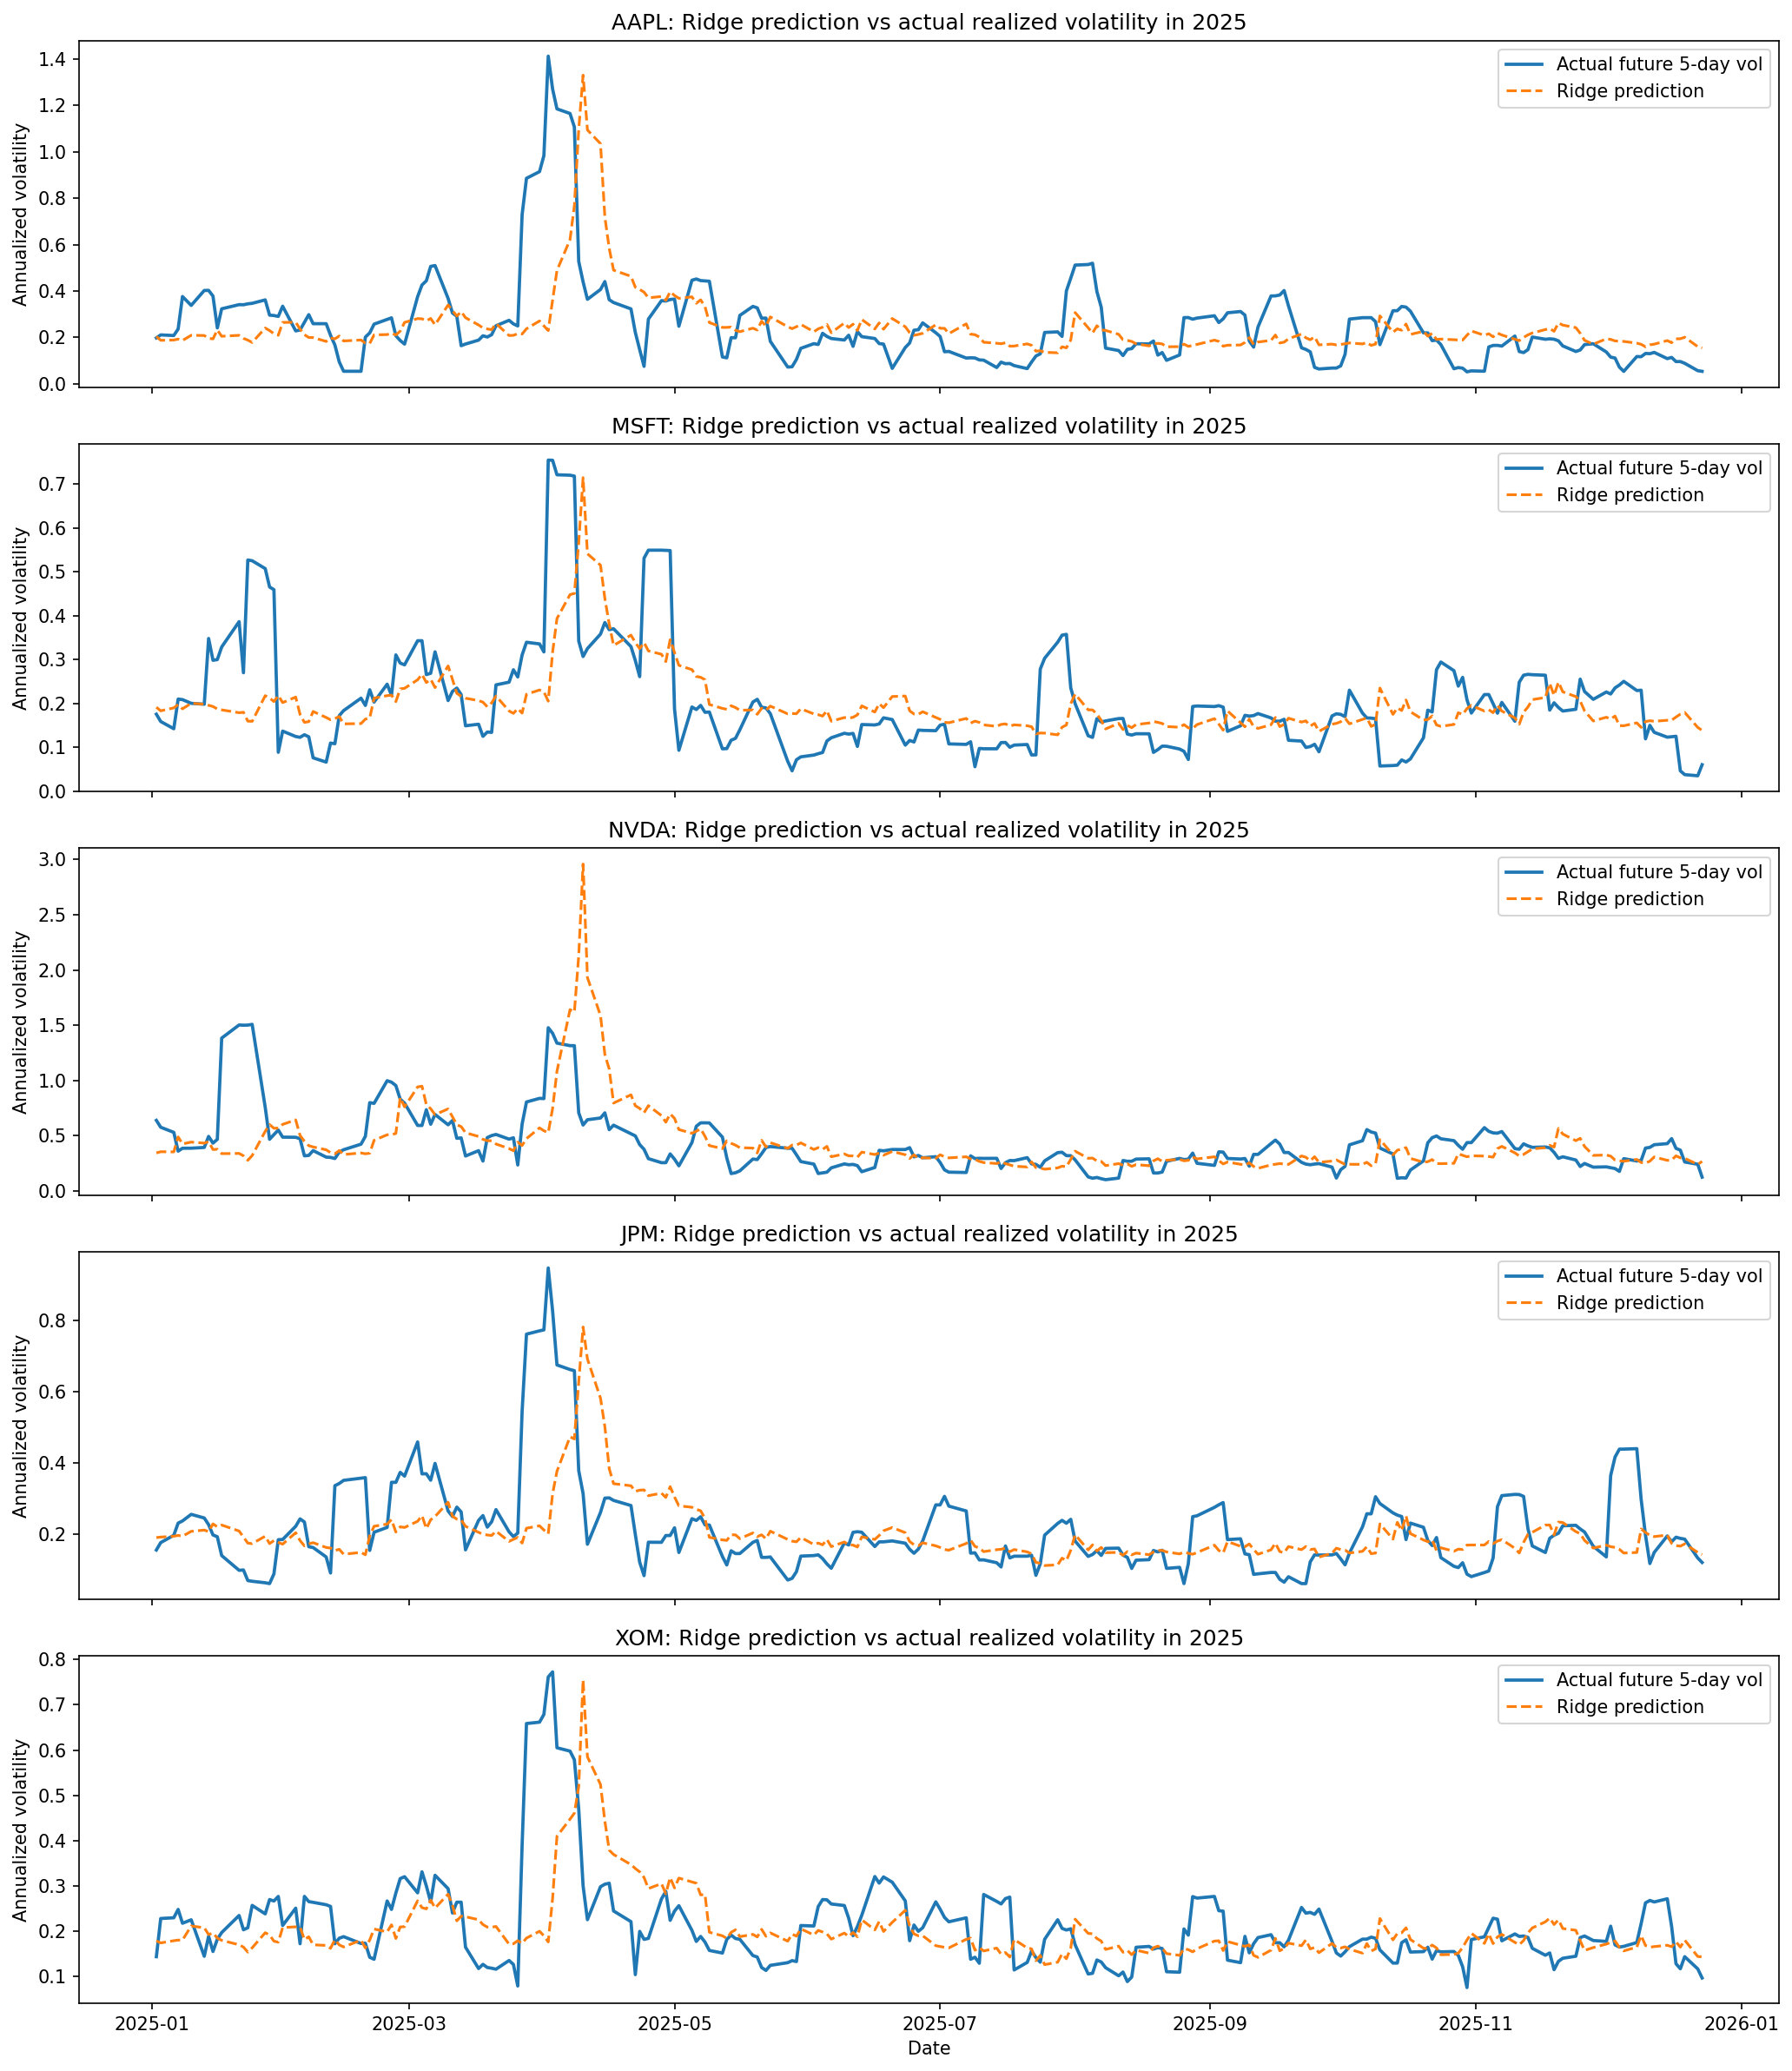

PosixPath('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project/figures/ridge_test_predictions_5stocks.png')

In [9]:
fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 16), sharex=True)

for ax, ticker in zip(axes, selected_tickers):
    stock_plot_df = ridge_predictions_df[ridge_predictions_df['Ticker'] == ticker].sort_values('Date')
    ax.plot(stock_plot_df['Date'], stock_plot_df['fvol_5d'], label='Actual future 5-day vol', linewidth=1.8)
    ax.plot(stock_plot_df['Date'], stock_plot_df['prediction'], label='Ridge prediction', linestyle='--', linewidth=1.5)
    ax.set_title(f'{ticker}: Ridge prediction vs actual realized volatility in 2025')
    ax.set_ylabel('Annualized volatility')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()

ridge_plot_path = FIGURE_DIR / 'ridge_test_predictions_5stocks.png'
plt.savefig(ridge_plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(ridge_plot_path)))

ridge_plot_path

## How to compare this with HAR-RV

The cleanest comparison is:

- same target,
- same expanding-window validation years,
- same 2025 holdout test,
- same five-stock prediction plot.

If Ridge beats HAR-RV, that suggests the extra range, liquidity, market, and macro information matters even before we move to nonlinear models.